In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp 
import scipy.io as sio
import cvxpy as cvx 
# set random seed
np.random.seed(42)

We consider the following continuously stirred tank reactor dynamics with a fractional rate law, obtained from Exercise Problem 7.7 of Kravaris and Kookos: $\dot{x} = f_0(x)+f_1(x)u$,  in which
$$ f_0(x) = \begin{bmatrix}
    \frac{3-x_1}{4} - \frac{9(1+x_1)}{4(3+2x_1)} \\
    -\frac{3(1+x_2)}{4} + \frac{9(1+x_1)}{4(3+2x_1)}
\end{bmatrix}, \enspace 
f_1(x) = \begin{bmatrix}
    \frac{3-x_1}{4} \\
    -\frac{1+x_2}{4}
\end{bmatrix}.$$
Physically, $u$ is the throughput flow rate passing the tank, $x_1$ is the intermediate concentration, and $x_2$ is the product concentration, all in relative deviation ratios from their steady state values. We assume that $f_1$ (associated with convection dynamics) is known, while $f_0$ (containing kinetics is unknown), but parameterized nonlinear as 
$$f_0(x|\theta)=\begin{bmatrix}
    -\frac{1}{4}x_1-\theta_1x_1-\theta_2x_1^2 \\
    -\frac{3}{4}x_2+\theta_1x_1+\theta_2x_1^2
\end{bmatrix}$$ 
with parameters $\theta_1, \theta_2\in [0, 1]$. 

In [2]:
f0 = lambda x : np.array([(3-x[0])/4 - 9/4*(1+x[0])/(3+2*x[0]), -3/4*(1+x[1]) + 9/4*(1+x[0])/(3+2*x[0])])
f1 = lambda x : np.array([(3-x[0])/4, -1/4*(1+x[1])])
f0_par = lambda x, theta: np.array([-x[0]/4 - theta[0]*x[0] - theta[1]*x[0]**2, -3/4*x[1] + theta[0]*x[0] + theta[1]*x[0]**2])
n, m, q = 200, 25, 3
r = 0.25
N = 2*q 
psi = lambda x: np.array([x[0]**i for i in range(1, q+1)] + [x[0]**(i-1)*x[1] for i in range(1, q+1)])
Dpsi0 = lambda x: np.array([i*x[0]**(i-1) for i in range(1, q+1)] + [(0 if i==1 else (i-1)*x[0]**(i-2)*x[1]) for i in range(1, q+1)])
Dpsi1 = lambda x: np.array([0 for i in range(1, q+1)] + [x[0]**(i-1) for i in range(1, q+1)])
Dpsi = lambda x: np.vstack((Dpsi0(x), Dpsi1(x))).T

x_sample = r*(np.random.random((n, 2)) * 2 - 1)
psi_sample = np.array([psi(x) for x in x_sample])
theta_sample = np.random.random((m, 2))

drift0_sample = np.array([ (Dpsi(x) @ f0(x)).flatten() for x in x_sample ])
drift0_samples_par = []
for j in range(m):
    drift0_sample_par = np.array([ (Dpsi(x) @ f0_par(x, theta_sample[j])).flatten() for x in x_sample ])
    drift0_samples_par.append(drift0_sample_par)
A = [(np.linalg.lstsq(psi_sample, drift0_samples_par[j], rcond=None)[0]).T for j in range(m)]
drift1_sample = np.array([ (Dpsi(x) @ f1(x)).flatten() for x in x_sample ])
psi_sample_augmented = np.hstack((psi_sample, np.ones((n, 1))))
B_augmented = (np.linalg.lstsq(psi_sample_augmented, drift1_sample, rcond=None)[0]).T
B = B_augmented[:, :-1]
beta = B_augmented[:, -1]

## 1. Identification
The formulation is 
$$\begin{aligned}
    \min_{b\in \mathbb{R}^m, R\in \mathbb{R}^{N\times N}}  & \sum_{i=1}^n \left\| \sum_{j=1}^m b_j\mathrm{D}\psi\cdot f_0(x_i|\theta_j) + R\psi(x_i) - \dot{\psi}(x_i) \right\|^2  + \lambda_R\|R\|_{\mathrm{F}}^2 \\
    \mathrm{s.t.} \enspace & b\geq 0, \enspace e^\top b=1. 
\end{aligned} $$


lambda: 1e-05, optimal value: 0.0007536966738523601
lambda: 1e-05, training error: 0.0011, validation error: 0.0011
lambda: 0.0001, optimal value: 0.004000279799596157


C:\Users\wtang23\AppData\Local\Temp\ipykernel_14800\754870109.py:23: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  drift0_pred = np.array([ np.sum(b_opt[j] * (Dpsi(x) @ f0_par(x, theta_sample[j])).flatten() for j in range(m)) + (R_opt @ psi(x)).flatten() for x in x_test ])
C:\Users\wtang23\AppData\Local\Temp\ipykernel_14800\754870109.py:28: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  drift0_sample_pred = np.array([ np.sum(b_opt[j] * (Dpsi(x) @ f0_par(x, theta_sample[j])).flatten() for j in range(m)) + (R_opt @ psi(x)).flatten() for x in x_sample ])


lambda: 0.0001, training error: 0.0021, validation error: 0.0020
lambda: 0.001, optimal value: 0.0197474658630997
lambda: 0.001, training error: 0.0069, validation error: 0.0066
lambda: 0.01, optimal value: 0.04296338424693537
lambda: 0.01, training error: 0.0132, validation error: 0.0123
lambda: 0.1, optimal value: 0.05385298705896923
lambda: 0.1, training error: 0.0161, validation error: 0.0149
lambda: 1.0, optimal value: 0.05589199759060376
lambda: 1.0, training error: 0.0167, validation error: 0.0155
lambda: 10.0, optimal value: 0.056121567963995485
lambda: 10.0, training error: 0.0167, validation error: 0.0155
lambda: 100.0, optimal value: 0.05614483186365983
lambda: 100.0, training error: 0.0168, validation error: 0.0155
lambda: 1000.0, optimal value: 0.056147161383341235
lambda: 1000.0, training error: 0.0168, validation error: 0.0156


Text(0, 0.5, '$\\|R\\|_{\\mathrm{F}}$')

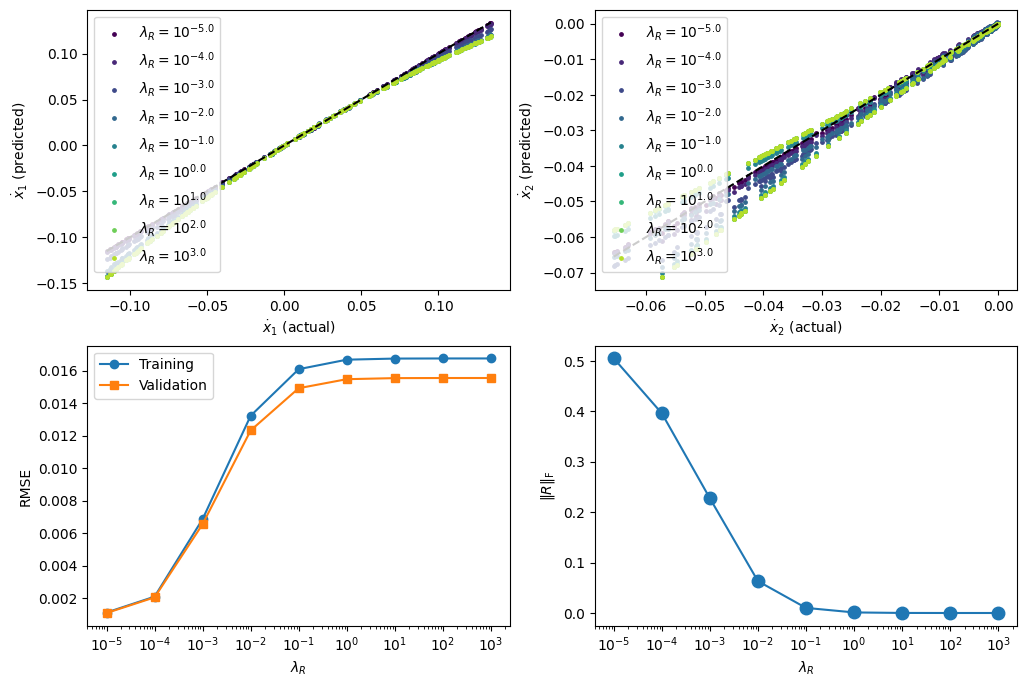

In [3]:
b = cvx.Variable(m, nonneg=True)
R = cvx.Variable((N, N))
lambda_range = np.logspace(-5, 3, 9)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
cm = plt.get_cmap('viridis')
x_test = r*(np.random.random((n, 2)) * 2 - 1)
drift0_test = np.array([ (Dpsi(x) @ f0(x)).flatten() for x in x_test ])
DRIFT_PAR = np.array(drift0_samples_par).reshape(m, -1) 
train_errors, val_errors, R_magnitudes = [], [], []
dynamics = []

for k in range(len(lambda_range)):
    lambda_ = lambda_range[k]
    obj = cvx.Minimize( cvx.sum_squares(DRIFT_PAR.T@b + cvx.vec(psi_sample@R.T, 'C') - cvx.vec(drift0_sample, 'C')) + n*lambda_*cvx.sum_squares(R) )
    prob = cvx.Problem(obj, [cvx.sum(b) == 1])
    prob.solve()
    print(f'lambda: {lambda_}, optimal value: {prob.value}')
    b_opt, R_opt = b.value, R.value
    A_opt = (np.array(A).T @ b_opt).T + R_opt # The trained dynamics
    dynamics.append((A_opt, B, beta)) 

    # plot predicted \dot{x} versus true \dot{x}
    drift0_pred = np.array([ np.sum(b_opt[j] * (Dpsi(x) @ f0_par(x, theta_sample[j])).flatten() for j in range(m)) + (R_opt @ psi(x)).flatten() for x in x_test ])
    axes[0, 0].scatter(drift0_test[:, 0], drift0_pred[:, 0], s=6, color=cm(k/len(lambda_range)), label=r'$\lambda_R=10^{' + f'{np.log10(lambda_):.1f}' + r'}$')
    axes[0, 1].scatter(drift0_test[:, 1], drift0_pred[:, 1], s=6, color=cm(k/len(lambda_range)), label=r'$\lambda_R=10^{' + f'{np.log10(lambda_):.1f}' + r'}$')
    
    # record training and validation errors
    drift0_sample_pred = np.array([ np.sum(b_opt[j] * (Dpsi(x) @ f0_par(x, theta_sample[j])).flatten() for j in range(m)) + (R_opt @ psi(x)).flatten() for x in x_sample ])
    train_error = np.sqrt(np.mean(np.linalg.norm(drift0_sample - drift0_sample_pred, axis=1)**2))
    val_error = np.sqrt(np.mean(np.linalg.norm(drift0_test - drift0_pred, axis=1)**2))
    print(f'lambda: {lambda_}, training error: {train_error:.4f}, validation error: {val_error:.4f}')
    train_errors.append(train_error)
    val_errors.append(val_error)
    # record R magnitude
    R_magnitude = np.linalg.norm(R_opt, 'fro')
    R_magnitudes.append(R_magnitude)
    
axes[0, 0].plot([np.min(drift0_test[:, 0]), np.max(drift0_test[:, 0])], [np.min(drift0_test[:, 0]), np.max(drift0_test[:, 0])], 'k--')
axes[0, 1].plot([np.min(drift0_test[:, 1]), np.max(drift0_test[:, 1])], [np.min(drift0_test[:, 1]), np.max(drift0_test[:, 1])], 'k--')
axes[0, 0].legend(), axes[0, 0].set_xlabel(r'$\dot{x}_1$ (actual)'), axes[0, 0].set_ylabel(r'$\dot{x}_1$ (predicted)')
axes[0, 1].legend(), axes[0, 1].set_xlabel(r'$\dot{x}_2$ (actual)'), axes[0, 1].set_ylabel(r'$\dot{x}_2$ (predicted)')
axes[1, 0].semilogx(lambda_range, train_errors, marker='o', label='Training')
axes[1, 0].semilogx(lambda_range, val_errors, marker='s', label='Validation')
axes[1, 0].set_xlabel(r'$\lambda_R$')
axes[1, 0].set_ylabel('RMSE')
axes[1, 0].legend()
axes[1, 1].semilogx(lambda_range, R_magnitudes, marker='o', markersize=9) 
axes[1, 1].set_xlabel(r'$\lambda_R$')
axes[1, 1].set_ylabel(r'$\|R\|_{\mathrm{F}}$')

Put $\lambda_R=0.1$ and re-train. 

Extract the values of $\beta$, $A$, $B$, and $R$, needed for doing control. The model is as follows, for a single-input system. 
$$\dot{z}\approx \left(\sum_{j=1}^m b_j^* A_{0j} + R^*\right) z + u(\beta+Bz) \to Az + u(\beta + Bz). $$

## 2. Lyapunov-based Control


In [4]:
sontag = lambda a, b: (-(a+np.sqrt(a**2+b**2))/b/(1+np.sqrt(1+b)) if b != 0 else 0)
term1_x = lambda x: np.inner(Dpsi(x).T @ psi(x), f0(x))
term2_x = lambda x: np.inner(Dpsi(x).T @ psi(x), f1(x))
sontag_x = lambda x: sontag(term1_x(x), term2_x(x)**2) * term2_x(x)
closed_loop_drift_x = lambda t, x: f0(x) + f1(x)*sontag_x(x)

def sontag_control(z, A, B, beta):
    term1 = np.inner(z, A @ z)
    term2 = np.inner(z, B @ z + beta)
    return sontag(term1, term2**2) * term2
closed_loop_drift_z = lambda t, x, A, B, beta: f0(x) + f1(x)*sontag_control(psi(x), A, B, beta)

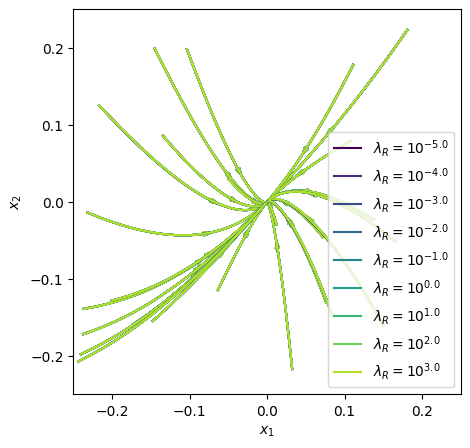

(<matplotlib.legend.Legend at 0x28846aa6710>, None)

In [5]:
# Compare the flows under the two controls
fig, ax = plt.subplots(figsize=(5, 5))
cm = plt.get_cmap('viridis')

initial_conditions = r*(np.random.random((25, 2)) * 2 - 1)
t_span = (0, 10)
for count in range(len(initial_conditions)):
    x0 = initial_conditions[count]
    sol_x = sp.integrate.solve_ivp(closed_loop_drift_x, t_span, x0, t_eval=np.linspace(t_span[0], t_span[1], 101))
    plt.plot(sol_x.y[0], sol_x.y[1], color='k')
    plt.arrow(sol_x.y[0][15], sol_x.y[1][15], sol_x.y[0][16]-sol_x.y[0][15], sol_x.y[1][16]-sol_x.y[1][15], 
              color='k', head_width=0.005, head_length=0.01)
    for k in range(len(lambda_range)):
        A_opt, B, beta = dynamics[k]
        closed_loop_drift_z_k = lambda t, x: closed_loop_drift_z(t, x, A_opt, B, beta)
        sol_z_k = sp.integrate.solve_ivp(closed_loop_drift_z_k, t_span, x0, t_eval=np.linspace(t_span[0], t_span[1], 101))
        if count == 0:
            plt.plot(sol_z_k.y[0], sol_z_k.y[1], color=cm(k/len(lambda_range)), label=r'$\lambda_R=10^{' + f'{np.log10(lambda_range[k]):.1f}' + r'}$')
        else:
            plt.plot(sol_z_k.y[0], sol_z_k.y[1], color=cm(k/len(lambda_range)))
        plt.arrow(sol_z_k.y[0][15], sol_z_k.y[1][15], sol_z_k.y[0][16]-sol_z_k.y[0][15], sol_z_k.y[1][16]-sol_z_k.y[1][15], 
                  color=cm(k/len(lambda_range)), head_width=0.005, head_length=0.01)
plt.xlabel(r'$x_1$'), plt.ylabel(r'$x_2$')
plt.xlim(-r, r), plt.ylim(-r, r)
plt.legend(), plt.show()